# XGBoost Return Forecasting — All 3 Models

Trains and evaluates three XGBoost models that forecast each coin's **7-day-ahead price** on the test set. Each model is trained independently per coin (8 coins total). Forecasts are evaluated at each 7-day rebalance step and outputs are consumed by CMVO for portfolio optimisation.

---

## Models

### Model 1 — XGBoost Base
- **Features:** 14 lagged close prices
- **Target:** Close price 7 days ahead (direct price prediction)
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (`n_estimators=300`, `max_depth=6`, `lr=0.05`)
- **Output:** `xgboost_forecasts.csv`, RMSE1_normalized.csv`

### Model 2 — XGBoost Features
- **Features:** 14 lagged log returns + 30/60-day rolling volatility (lagged)
- **Target:** Log return 7 days ahead â†’ converted back to price
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (same as Base)
- **Output:** `xgb_feature_forecasts.csv`, `xgb_feature_rmses.csv`

### Model 3 — XGBoost Bayesian Optimised (BO)
- **Features:** 14 lagged close prices + 7-day rolling volatility
- **Target:** Close price 7 days ahead
- **Split:** 60/20/20 train/val/test
- **Hyperparameters:** Tuned with Optuna (30 trials, minimising val RMSE)
- **Output:** `xgboost_forecasts_BO_price_vol.csv`, `xgboost_rmse_summary_BO_price_vol.csv`

---

**Note:** Output CSVs are saved to the notebook's working directory. Tiny-price coins (median < 0.01) are log-transformed before training and inverse-transformed for evaluation.

In [1]:
import os
print(os.listdir("klines csv data/prices_cleaned"))

['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']


## Model 1 — XGBoost Base


Training: ADAUSDT
ADAUSDT RMSE: 0.157185
ADAUSDT Mean Actual Price: 0.528646
ADAUSDT NRMSE (% of mean price): 0.2973%


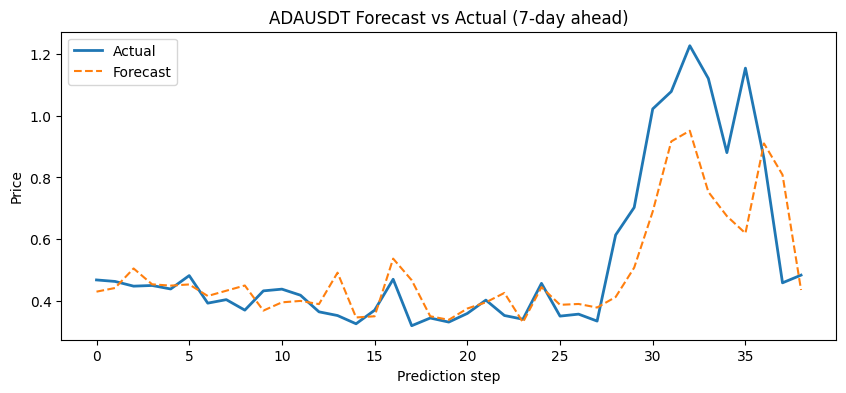


Training: BCHUSDT
BCHUSDT RMSE: 84.948199
BCHUSDT Mean Actual Price: 367.982051
BCHUSDT NRMSE (% of mean price): 0.2308%


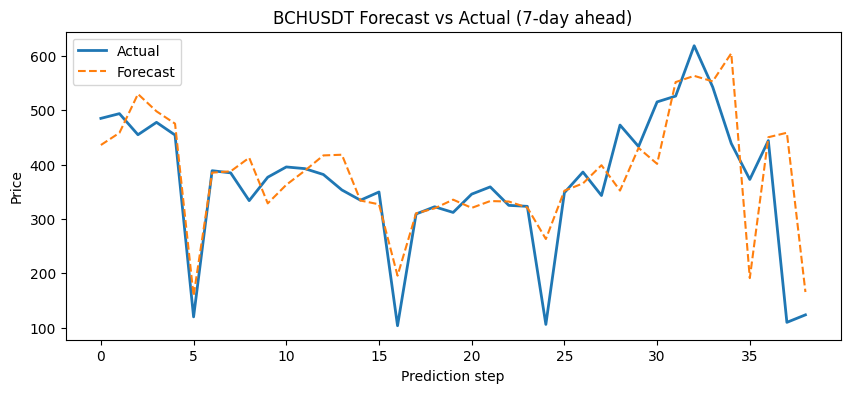


Training: BNBUSDT
BNBUSDT RMSE: 93.113759
BNBUSDT Mean Actual Price: 545.711282
BNBUSDT NRMSE (% of mean price): 0.1706%


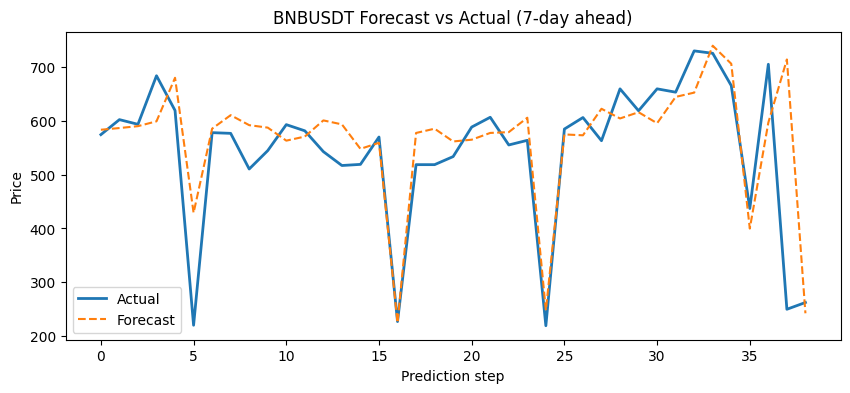


Training: BTCUSDT
BTCUSDT RMSE: 15443.041590
BTCUSDT Mean Actual Price: 64286.045128
BTCUSDT NRMSE (% of mean price): 0.2402%


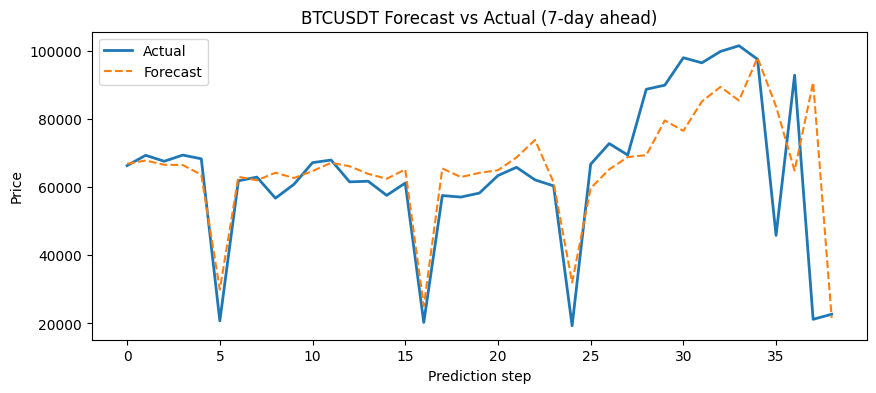


Training: ETHUSDT
ETHUSDT RMSE: 540.493945
ETHUSDT Mean Actual Price: 2851.582564
ETHUSDT NRMSE (% of mean price): 0.1895%


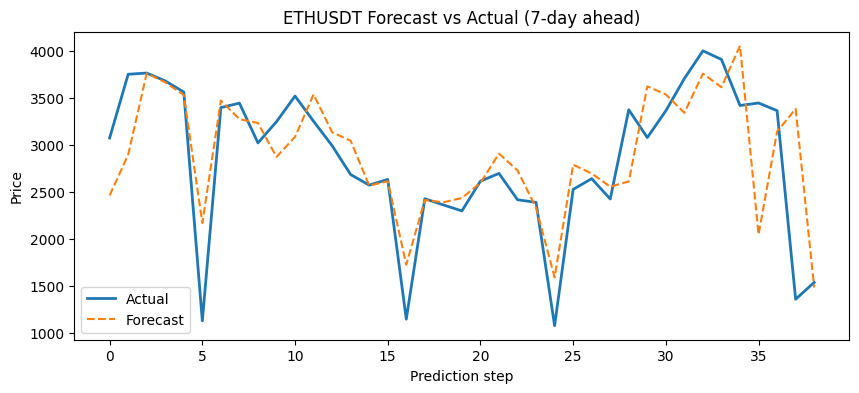


Training: SOLUSDT
SOLUSDT RMSE: 32.091526
SOLUSDT Mean Actual Price: 152.974615
SOLUSDT NRMSE (% of mean price): 0.2098%


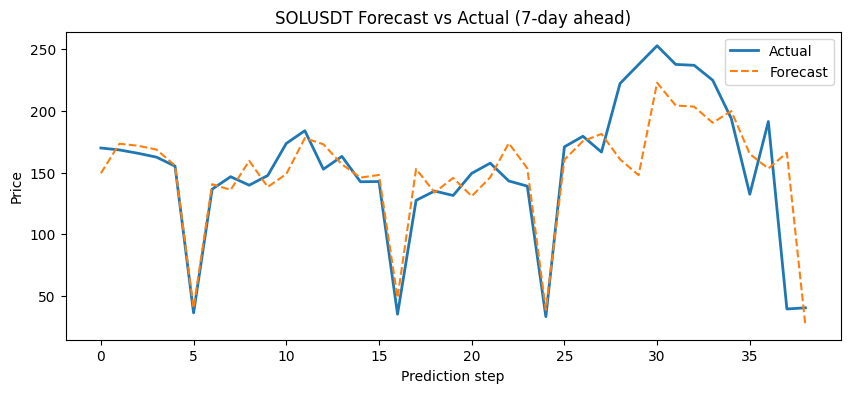


Training: TRXUSDT
TRXUSDT RMSE: 0.057499
TRXUSDT Mean Actual Price: 0.147867
TRXUSDT NRMSE (% of mean price): 0.3889%


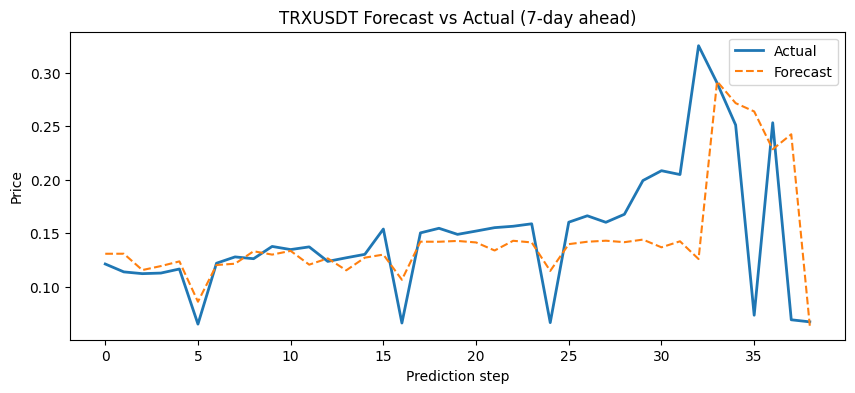


Training: XRPUSDT
XRPUSDT RMSE: 0.484355
XRPUSDT Mean Actual Price: 0.774849
XRPUSDT NRMSE (% of mean price): 0.6251%


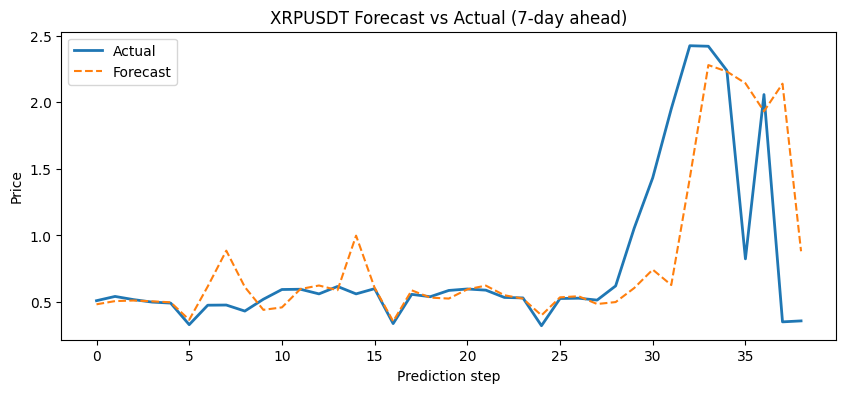

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4672,0.429138,-0.019561
1,ADAUSDT,0.4623,0.441001,-0.056076
2,ADAUSDT,0.4470,0.504433,0.091138
3,ADAUSDT,0.4492,0.452934,0.013274
4,ADAUSDT,0.4378,0.448726,-0.001055
...,...,...,...,...
307,XRPUSDT,2.2390,2.231719,-0.078449
308,XRPUSDT,0.8240,2.143665,-0.042579
309,XRPUSDT,2.0587,1.932928,1.345787
310,XRPUSDT,0.3505,2.140393,0.039682



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Mean,NRMSE_Percent
BNBUSDT,93.113759,545.711282,0.170628,0.170628
ETHUSDT,540.493945,2851.582564,0.189542,0.189542
SOLUSDT,32.091526,152.974615,0.209783,0.209783
BCHUSDT,84.948199,367.982051,0.230849,0.230849
BTCUSDT,15443.041590,64286.045128,0.240224,0.240224
ADAUSDT,0.157185,0.528646,0.297335,0.297335
TRXUSDT,0.057499,0.147867,0.388855,0.388855
XRPUSDT,0.484355,0.774849,0.625096,0.625096


In [2]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

def create_lags(df, n_lags):
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df["close"].shift(i)
    return df

files = os.listdir(data_folder)

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index","close","time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    df = df.sort_values("time")

    df = df[["close"]]

    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    df["target"] = df["close"].shift(-HORIZON)

    df = create_lags(df, N_LAGS)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=43
    )

    model.fit(X_train, y_train)

    preds = []
    actual = []
    current_prices = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]
        current_price_raw = X_test.iloc[i]['close']

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
            current_prices.append(np.exp(current_price_raw))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])
            current_prices.append(current_price_raw)

    preds = np.array(preds)
    actual = np.array(actual)
    current_prices = np.array(current_prices)

    rmse = np.sqrt(mean_squared_error(actual, preds))

    mean_actual_price = actual.mean()
    nrmse_mean = rmse / mean_actual_price
    nrmse_pct = nrmse_mean

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Mean": nrmse_mean,
        "NRMSE_Percent": nrmse_pct
    }

    print(f"{coin} RMSE: {rmse:.6f}")
    print(f"{coin} Mean Actual Price: {mean_actual_price:.6f}")
    print(f"{coin} NRMSE (% of mean price): {nrmse_pct:.4f}%")

    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (preds - current_prices) / current_prices
    })

    all_tables.append(table)

    plt.figure(figsize=(10,4))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

final_table = pd.concat(all_tables, ignore_index=True)

display(final_table)

final_table.to_csv("04 XGB results/xgboost_forecasts.csv", index=False)

rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("NRMSE_Percent")

rmse_table.to_csv("04 XGB results/RMSE1_normalized.csv", index=True)

print("\nRMSE Summary")
display(rmse_table)


In [3]:
np.save("Results/XGBoost Base Forecast new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("04 XGB results/RMSE1_normalized.npy", rmse_table.values)
print("Saved .npy files for Model 1 (Base)")

Saved .npy files for Model 1 (Base)


## Model 2 — XGBoost Features

c:\Users\ameli\Documents\all ur code projects\optimising-dynamic-crypto-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files detected: 8
['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']

Training: ADAUSDT
ADAUSDT RMSE: 0.25785613379192196


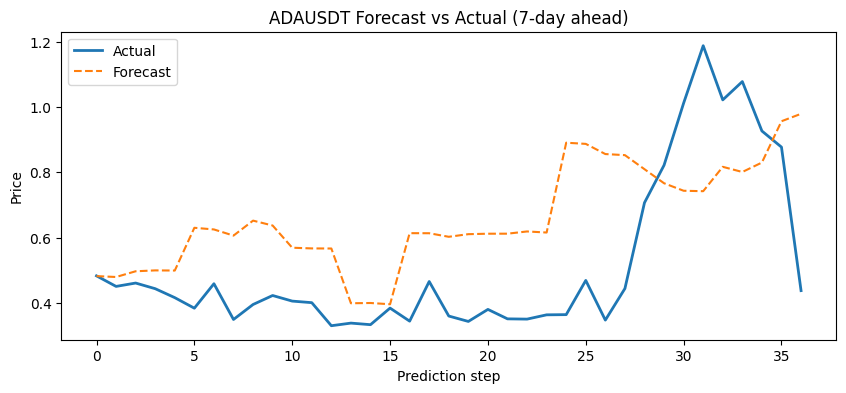


Training: BCHUSDT
BCHUSDT RMSE: 218.37718855179273


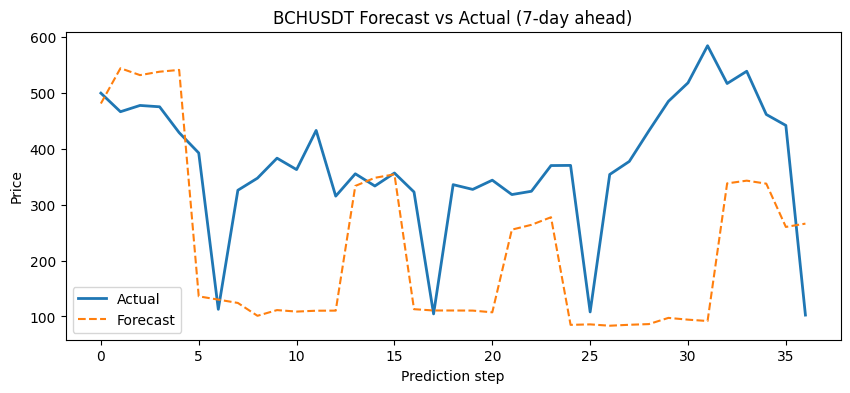


Training: BNBUSDT
BNBUSDT RMSE: 260.58204333215565


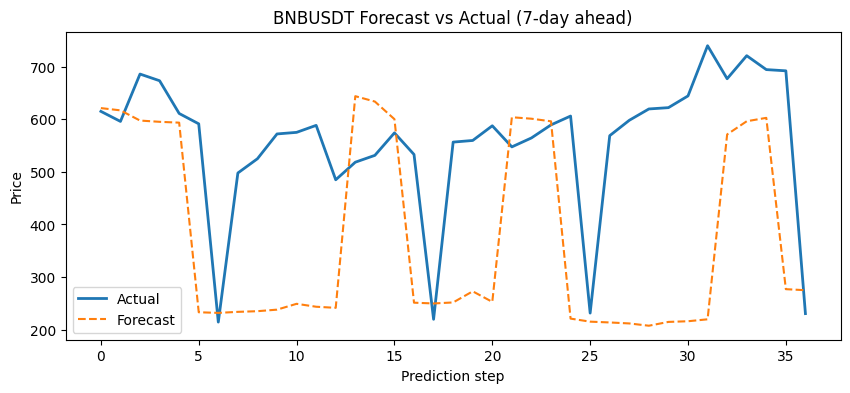


Training: BTCUSDT
BTCUSDT RMSE: 43021.14317577059


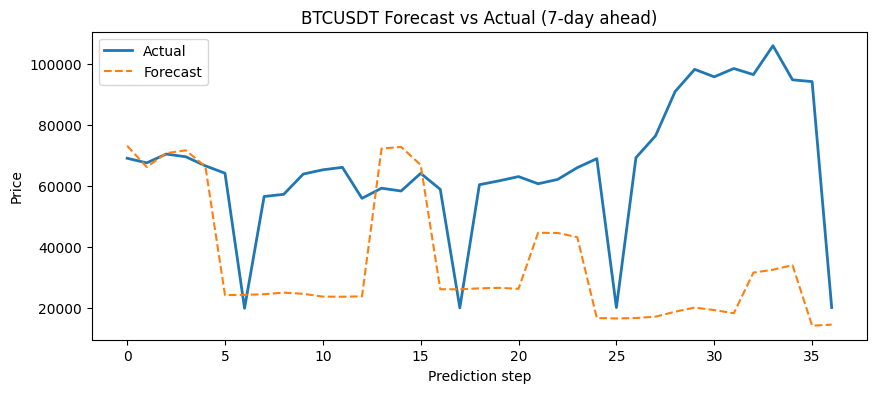


Training: ETHUSDT
ETHUSDT RMSE: 1501.2502679721706


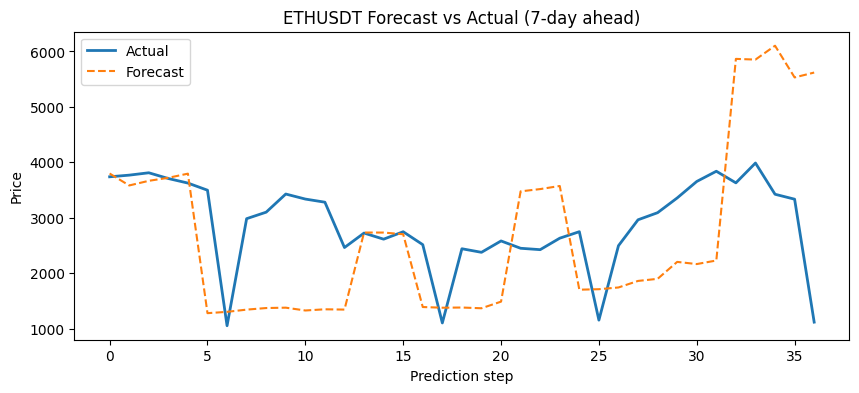


Training: SOLUSDT
SOLUSDT RMSE: 105.4910139675459


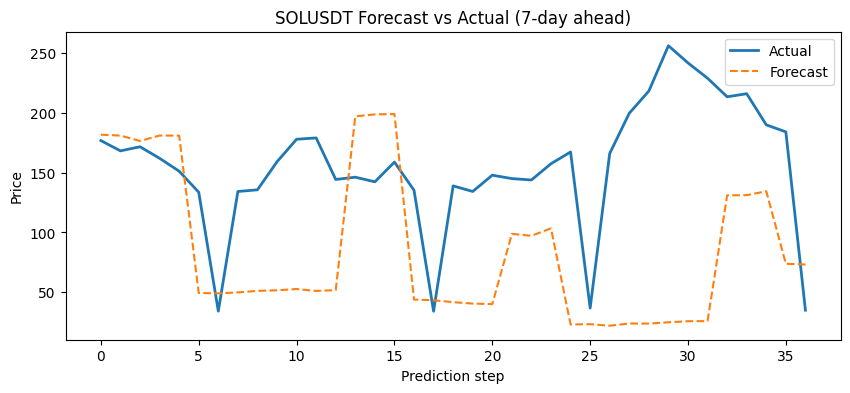


Training: TRXUSDT
TRXUSDT RMSE: 0.10136203504621331


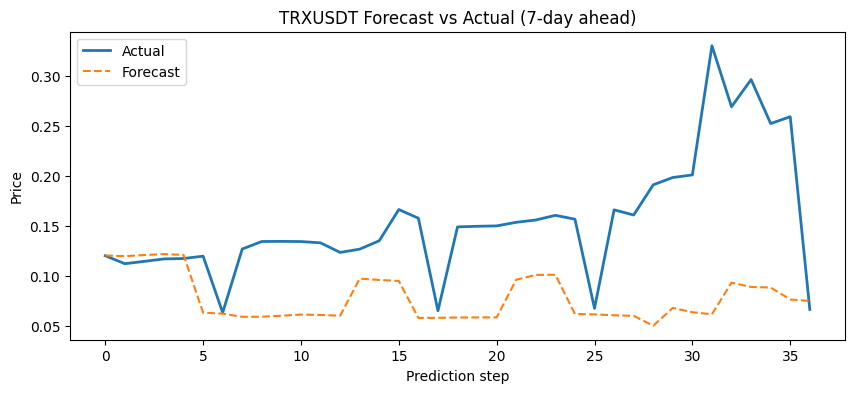


Training: XRPUSDT
XRPUSDT RMSE: 0.6354830162378924


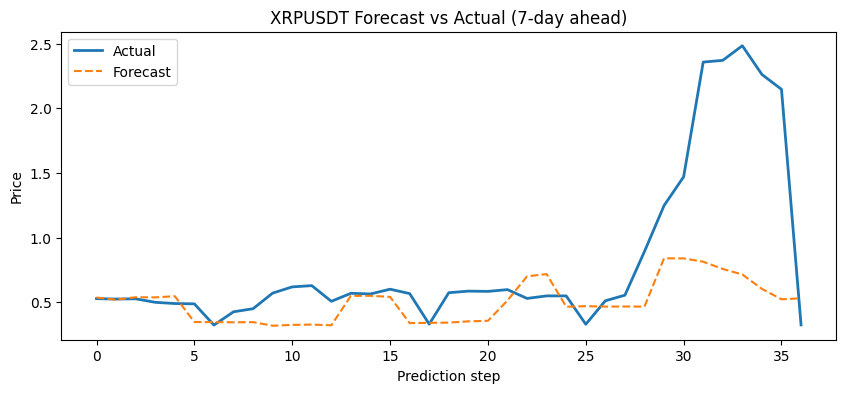

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4835,0.482660,-0.001739
1,ADAUSDT,0.4512,0.479980,-0.005567
2,ADAUSDT,0.4615,0.497486,0.035822
3,ADAUSDT,0.4442,0.500165,0.005370
4,ADAUSDT,0.4168,0.499699,-0.000932
...,...,...,...,...
32,XRPUSDT,2.3709,0.756929,-0.071117
33,XRPUSDT,2.4841,0.713815,-0.058646
34,XRPUSDT,2.2617,0.602571,-0.169419
35,XRPUSDT,2.1466,0.521954,-0.143625



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Percent
TRXUSDT,0.101362,0.155034,0.653807
ADAUSDT,0.257856,0.516959,0.498794
XRPUSDT,0.635483,0.813641,0.781037
SOLUSDT,105.491014,155.928108,0.676536
BCHUSDT,218.377189,372.651351,0.586009
BNBUSDT,260.582043,558.116486,0.466895
ETHUSDT,1501.250268,2895.692973,0.518442
BTCUSDT,43021.143176,66489.435946,0.647037


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"

HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

def create_lags(df, col, n_lags):

    for i in range(1, n_lags + 1):
        df[f"{col}_lag_{i}"] = df[col].shift(i)

    return df

files = os.listdir(data_folder)

print("Files detected:", len(files))
print(files[:10])

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")

    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)

    df.columns = ["index","close","time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    df = df.sort_values("time")
    df["return"] = np.log(df["close"] / df["close"].shift(1))

    df["vol_30"] = df["return"].rolling(30).std()
    df["vol_60"] = df["return"].rolling(60).std()

    df["target"] = df["return"].shift(-HORIZON)

    df = create_lags(df, "return", N_LAGS)
    df = create_lags(df, "vol_30", 10)
    df = create_lags(df, "vol_60", 10)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target","close","time"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    model = xgb.XGBRegressor(

        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=43

    )

    model.fit(X_train, y_train)

    preds_return = []
    actual_return = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        preds_return.append(pred)

        actual_return.append(y_test.iloc[i])


    actual_price = df["close"].iloc[split::7].values[:len(preds_return)]

    start_price = df["close"].iloc[split]

    preds_price = []

    price = start_price

    for r in preds_return:

        price = price * np.exp(r)

        preds_price.append(price)


    rmse = np.sqrt(mean_squared_error(actual_price, preds_price))
    mean_actual_price = np.mean(actual_price)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"{coin} RMSE:", rmse)

    table = pd.DataFrame({

        "coin": coin,
        "actual": actual_price,
        "forecast": preds_price,
        "returns_predicted": preds_return

    })

    all_tables.append(table)

    plt.figure(figsize=(10,4))

    plt.plot(actual_price, label="Actual", linewidth=2)
    plt.plot(preds_price, label="Forecast", linestyle="--")

    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")

    plt.legend()

    plt.show()



final_table = pd.concat(all_tables)

display(final_table)

final_table.to_csv("04 XGB results/xgb_feature_forecasts.csv", index=False)


rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\nRMSE Summary")
display(rmse_table)
rmse_table.to_csv("04 XGB results/xgb_feature_rmses.csv", index=True)

In [5]:
np.save("Results/XGBoost Features Forecast new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("04 XGB results/xgb_feature_rmses.npy", rmse_table.values)
print("Saved .npy files for Model 2 (Features)")

Saved .npy files for Model 2 (Features)


## Model 3 — XGBoost Bayesian Optimised (BO)


Training: ADAUSDT


C:\Users\ameli\AppData\Local\Temp\ipykernel_9804\4059106890.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-21 16:50:27,590] A new study created in memory with name: no-name-a593db80-8088-42bf-9738-62b286618fec


Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 1. Best value: 0.260717:   7%|▋         | 2/30 [00:00<00:02, 11.47it/s]

[I 2026-04-21 16:50:27,680] Trial 0 finished with value: 0.3505859400915919 and parameters: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}. Best is trial 0 with value: 0.3505859400915919.
[I 2026-04-21 16:50:27,763] Trial 1 finished with value: 0.26071665247021436 and parameters: {'n_estimators': 111, 'max_depth': 8, 'learning_rate': 0.08504050350189112, 'subsample': 0.9010235593143332, 'colsample_bytree': 0.6272105629299396, 'gamma': 0.284424683255759, 'reg_alpha': 4.333243204496001, 'reg_lambda': 1.1051449794218566}. Best is trial 1 with value: 0.26071665247021436.


...

[I 2026-04-21 16:50:31,439] Trial 25 finished with value: 0.22855412397412558 and parameters: {'n_estimators': 326, 'max_depth': 4, 'learning_rate': 0.09651589879298691, 'subsample': 0.7034237698548781, 'colsample_bytree': 0.6063392002197003, 'gamma': 0.45881464181033577, 'reg_alpha': 0.5992455158089169, 'reg_lambda': 1.6473392196728618}. Best is trial 23 with value: 0.19741584553438665.
[I 2026-04-21 16:50:31,542] Trial 26 finished with value: 0.29259422050828215 and parameters: {'n_estimators': 163, 'max_depth': 5, 'learning_rate': 0.07278575036097128, 'subsample': 0.7453000996943742, 'colsample_bytree': 0.5320617984565875, 'gamma': 1.5739500101563477, 'reg_alpha': 1.4844117800475405, 'reg_lambda': 0.7737413833430892}. Best is trial 23 with value: 0.19741584553438665.


Best trial: 23. Best value: 0.197416:  97%|█████████▋| 29/30 [00:04<00:00,  7.70it/s]

[I 2026-04-21 16:50:31,672] Trial 27 finished with value: 0.28452457693085864 and parameters: {'n_estimators': 174, 'max_depth': 3, 'learning_rate': 0.11773374635935677, 'subsample': 0.7945512846187024, 'colsample_bytree': 0.5846965286114123, 'gamma': 0.9842492186254099, 'reg_alpha': 3.1208461139644523, 'reg_lambda': 0.46446094933919496}. Best is trial 23 with value: 0.19741584553438665.
[I 2026-04-21 16:50:31,803] Trial 28 finished with value: 0.22440642289748072 and parameters: {'n_estimators': 231, 'max_depth': 4, 'learning_rate': 0.049963150142596356, 'subsample': 0.8878687027292863, 'colsample_bytree': 0.5381386396454513, 'gamma': 0.06432007417398591, 'reg_alpha': 2.434337569872167, 'reg_lambda': 3.2468600612872014}. Best is trial 23 with value: 0.19741584553438665.


Best trial: 23. Best value: 0.197416: 100%|██████████| 30/30 [00:04<00:00,  6.96it/s]


[I 2026-04-21 16:50:31,902] Trial 29 finished with value: 0.22338456494607506 and parameters: {'n_estimators': 135, 'max_depth': 7, 'learning_rate': 0.09879279403439414, 'subsample': 0.6446456247207666, 'colsample_bytree': 0.8900842609604038, 'gamma': 0.44314292792058013, 'reg_alpha': 0.2919908860942312, 'reg_lambda': 2.736028722710123}. Best is trial 23 with value: 0.19741584553438665.
Best params: {'n_estimators': 168, 'max_depth': 4, 'learning_rate': 0.08925965924802358, 'subsample': 0.7764809368323292, 'colsample_bytree': 0.5241682363255737, 'gamma': 0.0924846083650493, 'reg_alpha': 0.9273730812078486, 'reg_lambda': 0.5460780236873078}

Top 10 Most Important Features:
   feature  importance
     lag_1    0.372293
     close    0.256345
     lag_2    0.140155
     lag_5    0.060861
     lag_4    0.041993
     lag_3    0.039875
    lag_14    0.022222
volatility    0.017140
log_return    0.016980
    lag_13    0.016526

ADAUSDT RMSE: 0.079337


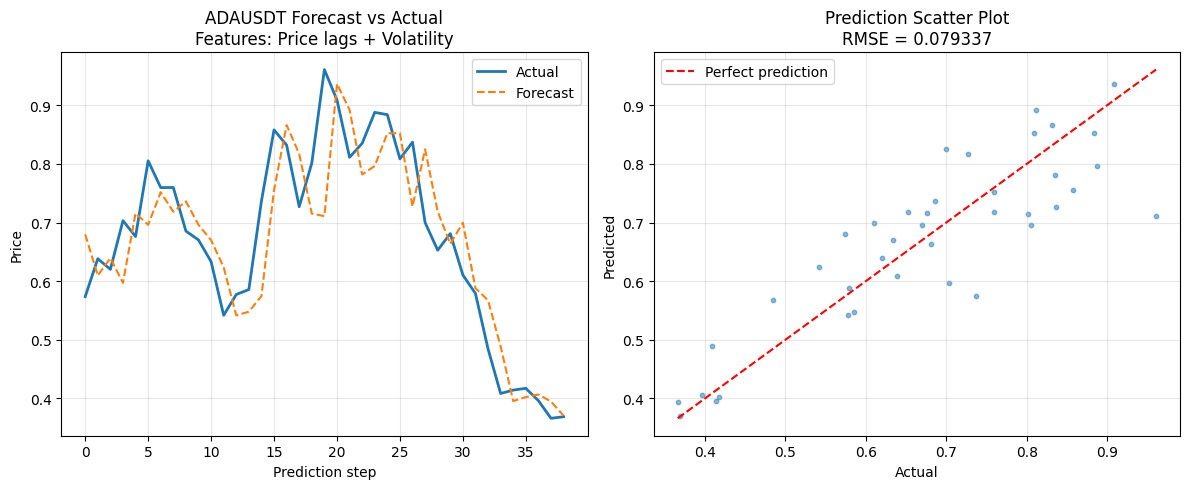

C:\Users\ameli\AppData\Local\Temp\ipykernel_9804\4059106890.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-21 16:50:32,745] A new study created in memory with name: no-name-9bf9ca92-a072-43cf-ae25-fb6d94085d87



Training: BCHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 57.9906:   3%|▎         | 1/30 [00:00<00:09,  2.94it/s]

[I 2026-04-21 16:50:33,085] Trial 0 finished with value: 57.99064855472214 and parameters: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}. Best is trial 0 with value: 57.99064855472214.


Best trial: 0. Best value: 57.9906:   7%|▋         | 2/30 [00:00<00:10,  2.79it/s]

...

[I 2026-04-21 16:50:40,801] Trial 27 finished with value: 58.227146749050746 and parameters: {'n_estimators': 323, 'max_depth': 3, 'learning_rate': 0.0732460936145121, 'subsample': 0.5014783308451448, 'colsample_bytree': 0.605907465267763, 'gamma': 4.183349546362057, 'reg_alpha': 2.2800802714777157, 'reg_lambda': 4.26654993613481}. Best is trial 10 with value: 55.66248911027868.


Best trial: 10. Best value: 55.6625:  97%|█████████▋| 29/30 [00:08<00:00,  4.45it/s]

[I 2026-04-21 16:50:41,015] Trial 28 finished with value: 57.651074190675196 and parameters: {'n_estimators': 175, 'max_depth': 4, 'learning_rate': 0.049963150142596356, 'subsample': 0.8383366286228474, 'colsample_bytree': 0.5713528342191175, 'gamma': 2.9935328832999994, 'reg_alpha': 4.941699846904747, 'reg_lambda': 2.9485686916159946}. Best is trial 10 with value: 55.66248911027868.


Best trial: 10. Best value: 55.6625: 100%|██████████| 30/30 [00:08<00:00,  3.46it/s]


[I 2026-04-21 16:50:41,401] Trial 29 finished with value: 61.54041104188958 and parameters: {'n_estimators': 143, 'max_depth': 7, 'learning_rate': 0.03970825409175857, 'subsample': 0.6308548367821373, 'colsample_bytree': 0.8900842609604038, 'gamma': 4.647669675788097, 'reg_alpha': 1.4804749554210994, 'reg_lambda': 2.736028722710123}. Best is trial 10 with value: 55.66248911027868.
Best params: {'n_estimators': 102, 'max_depth': 3, 'learning_rate': 0.06684789273543777, 'subsample': 0.5176198491514594, 'colsample_bytree': 0.5120392895721485, 'gamma': 4.61534750325524, 'reg_alpha': 1.6541375838514432, 'reg_lambda': 3.3528727887360086}

Top 10 Most Important Features:
feature  importance
  lag_1    0.297646
  close    0.276166
  lag_3    0.137510
  lag_2    0.118905
  lag_4    0.030421
  lag_6    0.029278
  lag_7    0.016545
  lag_9    0.013504
 lag_13    0.012178
 lag_12    0.011736

BCHUSDT RMSE: 65.810945


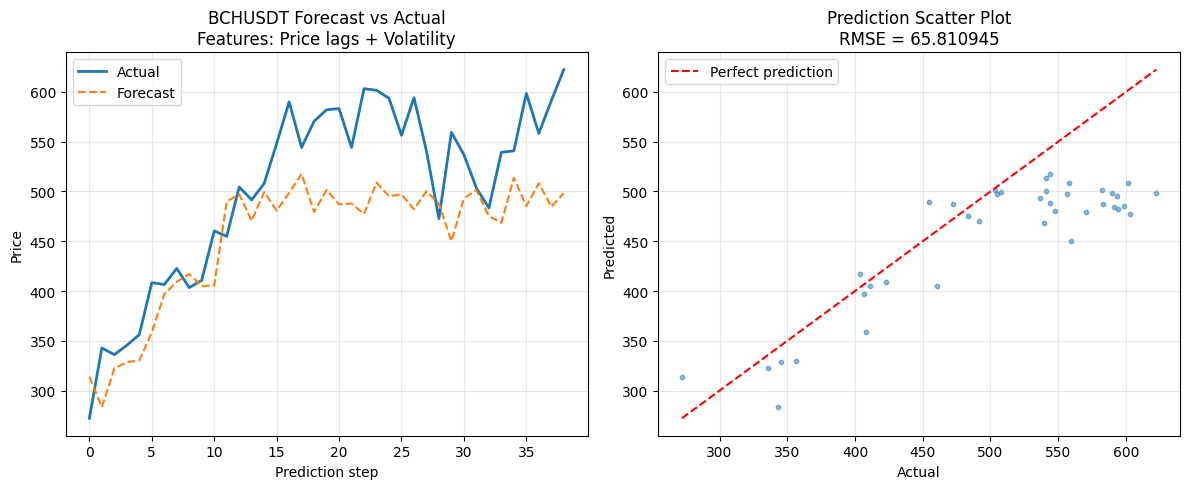

C:\Users\ameli\AppData\Local\Temp\ipykernel_9804\4059106890.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-21 16:50:42,428] A new study created in memory with name: no-name-84d9af35-63cf-4f05-8a9f-97eb2480995d



Training: BNBUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 73.4257:   3%|▎         | 1/30 [00:00<00:10,  2.85it/s]

[I 2026-04-21 16:50:42,775] Trial 0 finished with value: 73.42570938118642 and parameters: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}. Best is trial 0 with value: 73.42570938118642.


Best trial: 1. Best value: 70.9249:   7%|▋         | 2/30 [00:00<00:09,  3.09it/s]

...

[I 2026-04-21 16:50:54,969] Trial 27 finished with value: 71.38592471107705 and parameters: {'n_estimators': 316, 'max_depth': 5, 'learning_rate': 0.058365031277551147, 'subsample': 0.5874228449505835, 'colsample_bytree': 0.6251307479709278, 'gamma': 0.5898984432905658, 'reg_alpha': 3.024649901242524, 'reg_lambda': 2.467282625388446}. Best is trial 25 with value: 68.72370202767243.


Best trial: 25. Best value: 68.7237:  97%|█████████▋| 29/30 [00:13<00:00,  1.79it/s]

[I 2026-04-21 16:50:55,729] Trial 28 finished with value: 71.06728708327414 and parameters: {'n_estimators': 375, 'max_depth': 6, 'learning_rate': 0.026715627702779937, 'subsample': 0.7909666193174563, 'colsample_bytree': 0.7717604886031191, 'gamma': 1.1951881037208483, 'reg_alpha': 3.2413240297178025, 'reg_lambda': 0.6990712184749148}. Best is trial 25 with value: 68.72370202767243.


Best trial: 25. Best value: 68.7237: 100%|██████████| 30/30 [00:14<00:00,  2.11it/s]


[I 2026-04-21 16:50:56,610] Trial 29 finished with value: 71.72435403474772 and parameters: {'n_estimators': 234, 'max_depth': 7, 'learning_rate': 0.03970825409175857, 'subsample': 0.9937439097525912, 'colsample_bytree': 0.6744472785211708, 'gamma': 1.5215173460242424, 'reg_alpha': 2.6740693728872142, 'reg_lambda': 2.579135490660009}. Best is trial 25 with value: 68.72370202767243.
Best params: {'n_estimators': 321, 'max_depth': 3, 'learning_rate': 0.040247846191496156, 'subsample': 0.6329399353860398, 'colsample_bytree': 0.6175224291935726, 'gamma': 3.081590603964109, 'reg_alpha': 2.532440127386984, 'reg_lambda': 0.5064403972120587}

Top 10 Most Important Features:
feature  importance
  close    0.371187
  lag_1    0.274143
  lag_2    0.198160
  lag_3    0.078832
  lag_4    0.018892
  lag_5    0.010212
  lag_7    0.008925
 lag_14    0.005339
  lag_6    0.005116
 lag_13    0.005041

BNBUSDT RMSE: 213.432128


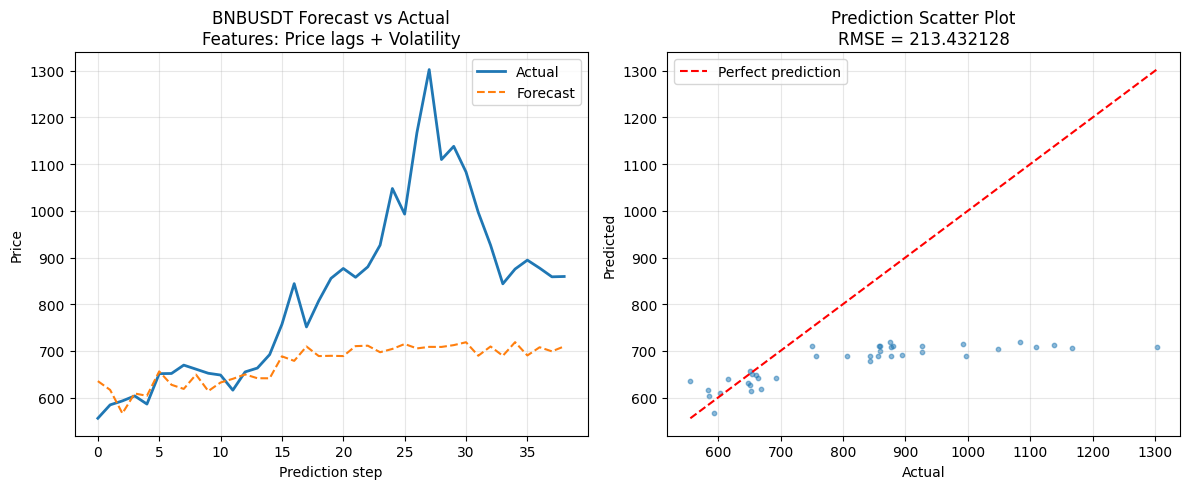

C:\Users\ameli\AppData\Local\Temp\ipykernel_9804\4059106890.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-21 16:50:57,805] A new study created in memory with name: no-name-879a7679-ea16-4c0e-82a8-bd819058cb3c



Training: BTCUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 24644.1:   3%|▎         | 1/30 [00:00<00:09,  3.06it/s]

[I 2026-04-21 16:50:58,128] Trial 0 finished with value: 24644.142343662756 and parameters: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}. Best is trial 0 with value: 24644.142343662756.


Best trial: 1. Best value: 24551.5:   7%|▋         | 2/30 [00:00<00:10,  2.55it/s]

...

[I 2026-04-21 16:51:15,733] Trial 27 finished with value: 21647.02154368692 and parameters: {'n_estimators': 465, 'max_depth': 3, 'learning_rate': 0.04232070659973003, 'subsample': 0.9331941386805851, 'colsample_bytree': 0.6934870374829817, 'gamma': 1.5061292676491664, 'reg_alpha': 2.950923739799045, 'reg_lambda': 0.6408237007690705}. Best is trial 16 with value: 20884.287680614096.


Best trial: 16. Best value: 20884.3:  97%|█████████▋| 29/30 [00:18<00:00,  1.96it/s]

[I 2026-04-21 16:51:16,255] Trial 28 finished with value: 22337.195821803027 and parameters: {'n_estimators': 424, 'max_depth': 4, 'learning_rate': 0.049963150142596356, 'subsample': 0.9715944653443894, 'colsample_bytree': 0.7053367908547503, 'gamma': 1.5866243497802028, 'reg_alpha': 2.934233987138567, 'reg_lambda': 0.58071438123663}. Best is trial 16 with value: 20884.287680614096.


Best trial: 16. Best value: 20884.3: 100%|██████████| 30/30 [00:19<00:00,  1.56it/s]


[I 2026-04-21 16:51:17,068] Trial 29 finished with value: 24392.447933187726 and parameters: {'n_estimators': 319, 'max_depth': 7, 'learning_rate': 0.03970825409175857, 'subsample': 0.9229566411691679, 'colsample_bytree': 0.7686630874460234, 'gamma': 2.1741063778865373, 'reg_alpha': 3.510658338291326, 'reg_lambda': 2.736028722710123}. Best is trial 16 with value: 20884.287680614096.
Best params: {'n_estimators': 413, 'max_depth': 3, 'learning_rate': 0.05830198592422048, 'subsample': 0.9989711682048606, 'colsample_bytree': 0.5684266643802507, 'gamma': 0.11550632322626389, 'reg_alpha': 2.2705918880881573, 'reg_lambda': 1.9590104232994312}

Top 10 Most Important Features:
feature  importance
  lag_1    0.271000
  lag_4    0.185683
  lag_5    0.157888
  close    0.146018
  lag_9    0.107721
  lag_6    0.073532
  lag_8    0.026742
  lag_2    0.017770
  lag_3    0.003508
 lag_12    0.002679

BTCUSDT RMSE: 13612.790216


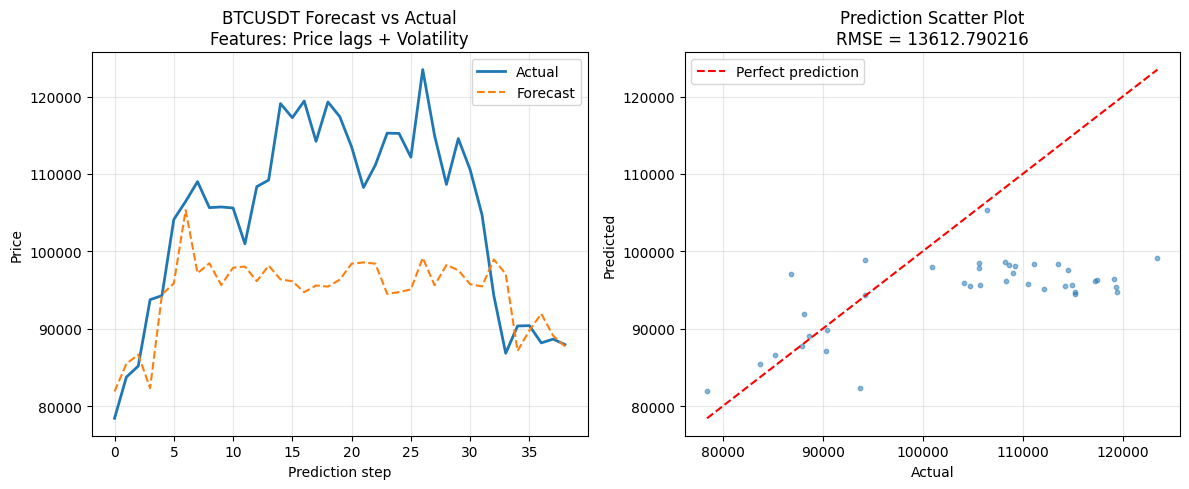

C:\Users\ameli\AppData\Local\Temp\ipykernel_9804\4059106890.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-21 16:51:18,178] A new study created in memory with name: no-name-9873acee-88fe-47a4-8ebc-b050312b44a3



Training: ETHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 305.774:   3%|▎         | 1/30 [00:00<00:16,  1.78it/s]

[I 2026-04-21 16:51:18,739] Trial 0 finished with value: 305.77352133947295 and parameters: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}. Best is trial 0 with value: 305.77352133947295.


Best trial: 1. Best value: 302.709:   7%|▋         | 2/30 [00:01<00:14,  1.93it/s]

...

[I 2026-04-21 16:51:29,952] Trial 27 finished with value: 298.4832490379463 and parameters: {'n_estimators': 243, 'max_depth': 4, 'learning_rate': 0.045345391812550845, 'subsample': 0.7312650221736843, 'colsample_bytree': 0.9970590840900296, 'gamma': 1.867944515877997, 'reg_alpha': 1.2762740414158276, 'reg_lambda': 3.6884631269233}. Best is trial 22 with value: 283.9841940216754.


Best trial: 22. Best value: 283.984:  97%|█████████▋| 29/30 [00:12<00:00,  3.06it/s]

[I 2026-04-21 16:51:30,362] Trial 28 finished with value: 315.1779896951882 and parameters: {'n_estimators': 317, 'max_depth': 3, 'learning_rate': 0.12857877743803087, 'subsample': 0.7972482799107189, 'colsample_bytree': 0.9117828811928874, 'gamma': 1.6036682085616278, 'reg_alpha': 4.941699846904747, 'reg_lambda': 2.98162327208242}. Best is trial 22 with value: 283.9841940216754.


Best trial: 22. Best value: 283.984: 100%|██████████| 30/30 [00:12<00:00,  2.35it/s]


[I 2026-04-21 16:51:30,924] Trial 29 finished with value: 307.3059364060426 and parameters: {'n_estimators': 139, 'max_depth': 7, 'learning_rate': 0.07775517719765254, 'subsample': 0.6786455707306909, 'colsample_bytree': 0.8132860876049871, 'gamma': 4.426957062611344, 'reg_alpha': 3.369692742657057, 'reg_lambda': 2.39197091828662}. Best is trial 22 with value: 283.9841940216754.
Best params: {'n_estimators': 152, 'max_depth': 3, 'learning_rate': 0.06528196230578687, 'subsample': 0.8956013967413611, 'colsample_bytree': 0.8186604320451336, 'gamma': 3.114469659122512, 'reg_alpha': 0.7847863692712536, 'reg_lambda': 4.346904714505044}

Top 10 Most Important Features:
feature  importance
  lag_2    0.350446
  close    0.316211
  lag_1    0.175381
  lag_4    0.069359
  lag_6    0.017636
  lag_5    0.008863
  lag_3    0.008553
  lag_8    0.007052
  lag_9    0.006753
 lag_12    0.005811

ETHUSDT RMSE: 541.699260


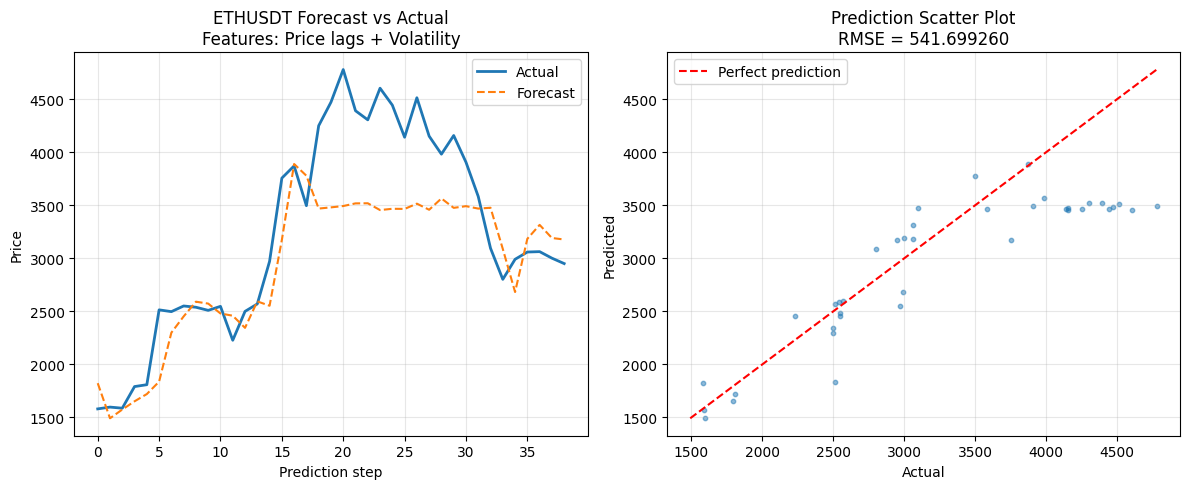

C:\Users\ameli\AppData\Local\Temp\ipykernel_9804\4059106890.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-21 16:51:31,917] A new study created in memory with name: no-name-c8507920-0587-4342-b82f-f2befdff2a03



Training: SOLUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 40.7442:   3%|▎         | 1/30 [00:00<00:08,  3.36it/s]

[I 2026-04-21 16:51:32,211] Trial 0 finished with value: 40.74415682847647 and parameters: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}. Best is trial 0 with value: 40.74415682847647.


Best trial: 1. Best value: 36.8814:   7%|▋         | 2/30 [00:00<00:08,  3.14it/s]

...

[I 2026-04-21 16:51:45,313] Trial 27 finished with value: 38.053953209104215 and parameters: {'n_estimators': 419, 'max_depth': 5, 'learning_rate': 0.16315916628961946, 'subsample': 0.54681347996244, 'colsample_bytree': 0.7300389219925173, 'gamma': 3.9327121471031394, 'reg_alpha': 1.73465332838069, 'reg_lambda': 0.24439427121782265}. Best is trial 11 with value: 32.437703643250416.


Best trial: 11. Best value: 32.4377:  97%|█████████▋| 29/30 [00:13<00:00,  2.05it/s]

[I 2026-04-21 16:51:45,872] Trial 28 finished with value: 39.56064728995864 and parameters: {'n_estimators': 324, 'max_depth': 7, 'learning_rate': 0.09573700312237798, 'subsample': 0.6993994785886813, 'colsample_bytree': 0.8795651771454663, 'gamma': 1.853021127693563, 'reg_alpha': 2.4795906394276117, 'reg_lambda': 3.2468600612872014}. Best is trial 11 with value: 32.437703643250416.


Best trial: 11. Best value: 32.4377: 100%|██████████| 30/30 [00:14<00:00,  2.10it/s]


[I 2026-04-21 16:51:46,187] Trial 29 finished with value: 38.56662966141838 and parameters: {'n_estimators': 215, 'max_depth': 7, 'learning_rate': 0.1258812458093811, 'subsample': 0.6268786902839893, 'colsample_bytree': 0.8014796835739572, 'gamma': 4.4808252806095075, 'reg_alpha': 3.2157836092668095, 'reg_lambda': 1.603373898191459}. Best is trial 11 with value: 32.437703643250416.
Best params: {'n_estimators': 494, 'max_depth': 10, 'learning_rate': 0.1713032613222943, 'subsample': 0.8377311933137364, 'colsample_bytree': 0.8308848312293458, 'gamma': 3.1919029760439215, 'reg_alpha': 2.0272764605350613, 'reg_lambda': 0.08544945445532537}

Top 10 Most Important Features:
   feature  importance
     close    0.827379
     lag_1    0.044206
     lag_2    0.041389
     lag_4    0.033727
     lag_9    0.008886
    lag_14    0.007435
     lag_3    0.006093
volatility    0.004912
     lag_6    0.004079
     lag_7    0.003842

SOLUSDT RMSE: 19.928424


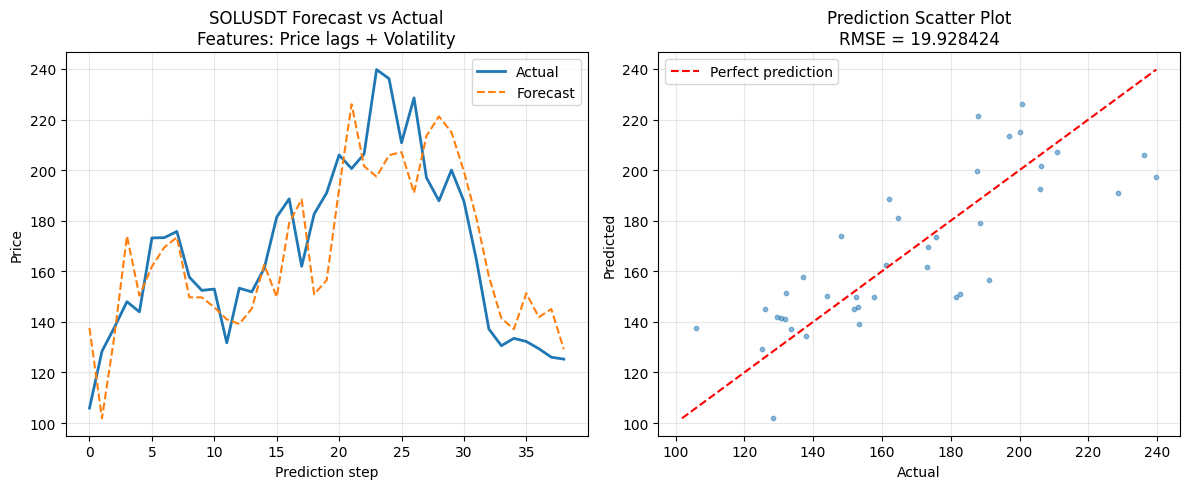

C:\Users\ameli\AppData\Local\Temp\ipykernel_9804\4059106890.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-21 16:51:47,373] A new study created in memory with name: no-name-9bb8a5e1-cc73-4291-b746-773ade2b2ac3



Training: TRXUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 0.12603:   7%|▋         | 2/30 [00:00<00:02, 12.74it/s]

[I 2026-04-21 16:51:47,466] Trial 0 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-21 16:51:47,529] Trial 1 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 111, 'max_depth': 8, 'learning_rate': 0.08504050350189112, 'subsample': 0.9010235593143332, 'colsample_bytree': 0.6272105629299396, 'gamma': 0.284424683255759, 'reg_alpha': 4.333243204496001, 'reg_lambda': 1.1051449794218566}. Best is trial 0 with value: 0.12602966170678476.


Best trial: 0. Best value: 0.12603:  13%|█▎        | 4/30 [00:00<00:02,  8.91it/s]

...

[I 2026-04-21 16:51:51,159] Trial 25 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 252, 'max_depth': 4, 'learning_rate': 0.04439228818445358, 'subsample': 0.9995879467120485, 'colsample_bytree': 0.8009959011324642, 'gamma': 1.941086350528575, 'reg_alpha': 1.8223682344460248, 'reg_lambda': 2.9635965280893455}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-21 16:51:51,337] Trial 26 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 309, 'max_depth': 5, 'learning_rate': 0.07573609858286806, 'subsample': 0.8942633299033328, 'colsample_bytree': 0.7440428176161594, 'gamma': 4.993567538495109, 'reg_alpha': 4.0889070940562275, 'reg_lambda': 2.3699312597393267}. Best is trial 0 with value: 0.12602966170678476.


Best trial: 0. Best value: 0.12603:  97%|█████████▋| 29/30 [00:04<00:00,  7.16it/s]

[I 2026-04-21 16:51:51,441] Trial 27 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 102, 'max_depth': 6, 'learning_rate': 0.1030620316919608, 'subsample': 0.9690622458392609, 'colsample_bytree': 0.6132485881172314, 'gamma': 3.7515721510468225, 'reg_alpha': 1.022475361218445, 'reg_lambda': 3.8785378320731563}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-21 16:51:51,565] Trial 28 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 138, 'max_depth': 3, 'learning_rate': 0.11954693961063464, 'subsample': 0.7369761708547813, 'colsample_bytree': 0.930093611246322, 'gamma': 4.448240365770496, 'reg_alpha': 2.5166856149051977, 'reg_lambda': 0.5956059510131193}. Best is trial 0 with value: 0.12602966170678476.


Best trial: 0. Best value: 0.12603: 100%|██████████| 30/30 [00:04<00:00,  6.90it/s]


[I 2026-04-21 16:51:51,715] Trial 29 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 201, 'max_depth': 8, 'learning_rate': 0.023904225571109394, 'subsample': 0.9414025261060054, 'colsample_bytree': 0.6466049922413002, 'gamma': 2.8858326229087026, 'reg_alpha': 4.551799983908715, 'reg_lambda': 2.9669075580630353}. Best is trial 0 with value: 0.12602966170678476.
Best params: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}

Top 10 Most Important Features:
   feature  importance
     close         0.0
log_return         0.0
volatility         0.0
     lag_1         0.0
     lag_2         0.0
     lag_3         0.0
     lag_4         0.0
     lag_5         0.0
     lag_6         0.0
     lag_7         0.0

TRXUSDT RMSE: 0.186881


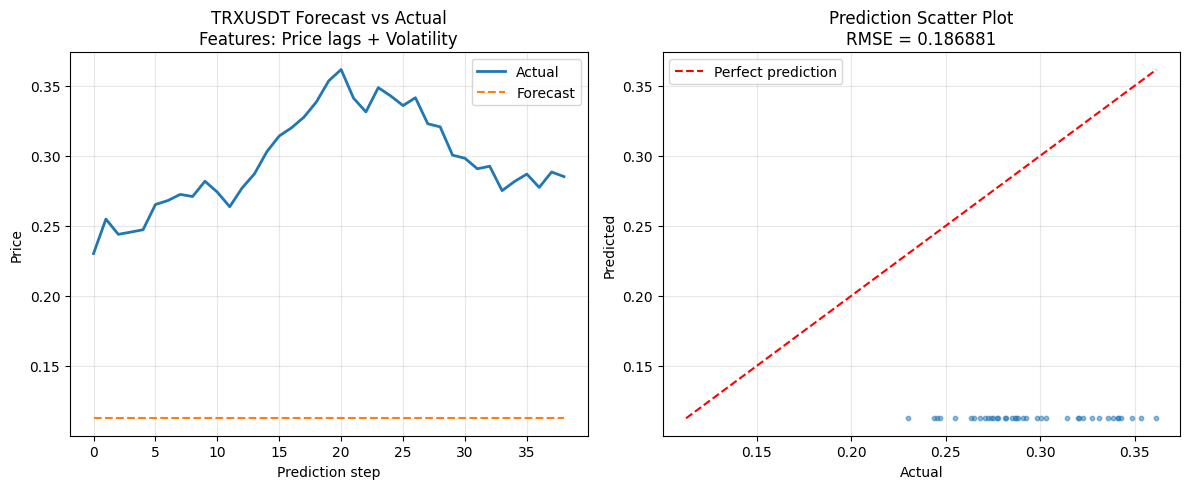

C:\Users\ameli\AppData\Local\Temp\ipykernel_9804\4059106890.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-21 16:51:52,490] A new study created in memory with name: no-name-a8bb2f5a-ca33-49ba-8dc7-19ee9bcc28f8



Training: XRPUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 1.39806:   0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-21 16:51:52,572] Trial 0 finished with value: 1.398061011572034 and parameters: {'n_estimators': 146, 'max_depth': 7, 'learning_rate': 0.03534428319533777, 'subsample': 0.6202948099826744, 'colsample_bytree': 0.6635695279055699, 'gamma': 4.295687454742988, 'reg_alpha': 3.330451065490129, 'reg_lambda': 2.7058110614170188}. Best is trial 0 with value: 1.398061011572034.


Best trial: 1. Best value: 1.34892:   7%|▋         | 2/30 [00:00<00:02, 12.49it/s]

...

[I 2026-04-21 16:51:56,012] Trial 24 finished with value: 1.3487495928208693 and parameters: {'n_estimators': 213, 'max_depth': 4, 'learning_rate': 0.13019244521559234, 'subsample': 0.7781215214341375, 'colsample_bytree': 0.5524492684649661, 'gamma': 0.773668568593552, 'reg_alpha': 0.9215760595816439, 'reg_lambda': 0.5819480141113904}. Best is trial 23 with value: 1.315067327812678.
[I 2026-04-21 16:51:56,179] Trial 25 finished with value: 1.3387688065072878 and parameters: {'n_estimators': 326, 'max_depth': 4, 'learning_rate': 0.09651589879298691, 'subsample': 0.7034237698548781, 'colsample_bytree': 0.6063392002197003, 'gamma': 0.45881464181033577, 'reg_alpha': 0.5992455158089169, 'reg_lambda': 1.6473392196728618}. Best is trial 23 with value: 1.315067327812678.


Best trial: 23. Best value: 1.31507:  93%|█████████▎| 28/30 [00:03<00:00,  7.22it/s]

[I 2026-04-21 16:51:56,309] Trial 26 finished with value: 1.3735080702712368 and parameters: {'n_estimators': 163, 'max_depth': 5, 'learning_rate': 0.07278575036097128, 'subsample': 0.7453000996943742, 'colsample_bytree': 0.5320617984565875, 'gamma': 1.5739500101563477, 'reg_alpha': 1.4844117800475405, 'reg_lambda': 0.7737413833430892}. Best is trial 23 with value: 1.315067327812678.
[I 2026-04-21 16:51:56,447] Trial 27 finished with value: 1.3678850112925098 and parameters: {'n_estimators': 174, 'max_depth': 3, 'learning_rate': 0.11773374635935677, 'subsample': 0.7945512846187024, 'colsample_bytree': 0.5846965286114123, 'gamma': 0.9842492186254099, 'reg_alpha': 3.1208461139644523, 'reg_lambda': 0.46446094933919496}. Best is trial 23 with value: 1.315067327812678.


Best trial: 23. Best value: 1.31507: 100%|██████████| 30/30 [00:04<00:00,  7.00it/s]


[I 2026-04-21 16:51:56,623] Trial 28 finished with value: 1.324977276016738 and parameters: {'n_estimators': 231, 'max_depth': 4, 'learning_rate': 0.049963150142596356, 'subsample': 0.8878687027292863, 'colsample_bytree': 0.5381386396454513, 'gamma': 0.06432007417398591, 'reg_alpha': 2.434337569872167, 'reg_lambda': 3.2468600612872014}. Best is trial 23 with value: 1.315067327812678.
[I 2026-04-21 16:51:56,774] Trial 29 finished with value: 1.3372739151766297 and parameters: {'n_estimators': 135, 'max_depth': 7, 'learning_rate': 0.09879279403439414, 'subsample': 0.6446456247207666, 'colsample_bytree': 0.8900842609604038, 'gamma': 0.44314292792058013, 'reg_alpha': 0.2919908860942312, 'reg_lambda': 2.736028722710123}. Best is trial 23 with value: 1.315067327812678.
Best params: {'n_estimators': 168, 'max_depth': 4, 'learning_rate': 0.08925965924802358, 'subsample': 0.7764809368323292, 'colsample_bytree': 0.5241682363255737, 'gamma': 0.0924846083650493, 'reg_alpha': 0.9273730812078486, 'r

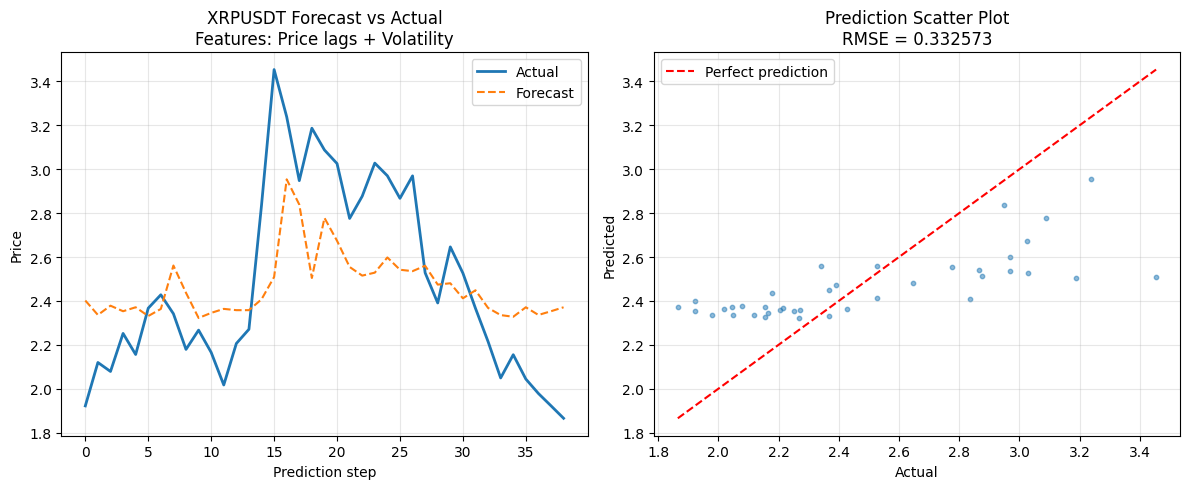


RMSE SUMMARY
                 RMSE  Mean_Actual_Price  NRMSE_Percent
ADAUSDT      0.079337           0.671769       0.118101
TRXUSDT      0.186881           0.296315       0.630684
XRPUSDT      0.332573           2.480085       0.134097
SOLUSDT     19.928424         167.505128       0.118972
BCHUSDT     65.810945         502.102564       0.131071
BNBUSDT    213.432128         820.774615       0.260037
ETHUSDT    541.699260        3219.931282       0.168233
BTCUSDT  13612.790216      104518.519744       0.130243

SUMMARY STATISTICS
Mean RMSE: 1806.782470
Median RMSE: 42.869685
Mean NRMSE (%): 0.2114%
Median NRMSE (%): 0.1326%
Best RMSE: 0.079337 (ADAUSDT)
Worst RMSE: 13612.790216 (BTCUSDT)


In [6]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14
VOLATILITY_WINDOW = 7

results = {}
all_tables = []

def create_features(df):
    df = df.copy()

    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    df["volatility"] = df["log_return"].rolling(window=VOLATILITY_WINDOW).std()

    for i in range(1, N_LAGS + 1):
        df[f"lag_{i}"] = df["close"].shift(i)

    return df

files = os.listdir(data_folder)

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv", "")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index", "close", "time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.sort_values("time")
    df = df[["close"]]

    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    df = create_features(df)

    df["target"] = df["close"].shift(-HORIZON)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target"])
    y = df["target"]

    split1 = int(len(df) * 0.6)
    split2 = int(len(df) * 0.8)

    X_train = X.iloc[:split1]
    X_val   = X.iloc[split1:split2]
    X_test  = X.iloc[split2:]

    y_train = y.iloc[:split1]
    y_val   = y.iloc[split1:split2]
    y_test  = y.iloc[split2:]

    print(f"Features used ({len(X.columns)} total):")
    price_lags = [col for col in X.columns if col.startswith("lag_")]
    vol_features = [col for col in X.columns if "vol" in col.lower()]
    other_features = [col for col in X.columns if col not in price_lags and col not in vol_features]

    print(f"  - Price lags: {len(price_lags)} features")
    print(f"  - Volatility features: {len(vol_features)} features")
    print(f"  - Other features: {len(other_features)} features")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")

    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "objective": "reg:squarederror",
            "random_state": 43
        }

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, verbose=False)

        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse

    sampler = optuna.samplers.TPESampler(seed=43)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best_params = study.best_params
    print("Best params:", best_params)

    model = xgb.XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=43
    )

    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_full, y_train_full, verbose=False)

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    preds = []
    actual = []
    current_prices = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]
        current_price_raw = X_test.iloc[i]['close']

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
            current_prices.append(np.exp(current_price_raw))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])
            current_prices.append(current_price_raw)

    preds = np.array(preds)
    actual = np.array(actual)
    current_prices = np.array(current_prices)

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mean_actual_price = np.mean(actual)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"\n{coin} RMSE: {rmse:.6f}")

    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (preds - current_prices) / current_prices
    })

    all_tables.append(table)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual\nFeatures: Price lags + Volatility")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(actual, preds, alpha=0.5, s=10)
    min_val = min(min(actual), min(preds))
    max_val = max(max(actual), max(preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect prediction")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Prediction Scatter Plot\nRMSE = {rmse:.6f}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

final_table = pd.concat(all_tables, ignore_index=True)
final_table.to_csv("04 XGB results/xgboost_forecasts_BO_price_vol.csv", index=False)

rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\n" + "="*60)
print("RMSE SUMMARY")
print("="*60)
print(rmse_table)
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Mean RMSE: {rmse_table['RMSE'].mean():.6f}")
print(f"Median RMSE: {rmse_table['RMSE'].median():.6f}")
print(f"Mean NRMSE (%): {rmse_table['NRMSE_Percent'].mean():.4f}%")
print(f"Median NRMSE (%): {rmse_table['NRMSE_Percent'].median():.4f}%")
print(f"Best RMSE: {rmse_table['RMSE'].min():.6f} ({rmse_table.index[rmse_table['RMSE'].argmin()]})")
print(f"Worst RMSE: {rmse_table['RMSE'].max():.6f} ({rmse_table.index[rmse_table['RMSE'].argmax()]})")

rmse_table.to_csv("04 XGB results/xgboost_rmse_summary_BO_price_vol.csv")


In [7]:
np.save("Results/Features and BO new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("04 XGB results/xgboost_rmse_summary_BO_price_vol.npy", rmse_table.values)
print("Saved .npy files for Model 3 (BO)")

Saved .npy files for Model 3 (BO)
